# Paper III: SMBH binaries with PLATO

TODO: write git version of last functional run!

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [2]:
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter

# PlatoSim libraries
import platosim.utilities as ut
from platosim.hpc          import HPC 
from platosim.lightcurve   import LightCurve
from platosim.slurm        import workerOverview
from platosim.matplotlibrc import setup_notebook
setup_notebook()

In [222]:
# Paths to where data is stored
path  = '/lhome/nicholas/software/workdir/cs-smbhb'
path0 = f'{path}/sim0_stellarContaminantsOn'
path1 = f'{path}/sim1_stellarContaminantsOff'

---
## Variable sources
---

### Generate files

In [4]:
hpc = HPC(cpus=6)
paramFile = f'{path}/data_varsource.txt'
# hpc.run(script='varsim', project='smbhb', paramFile=paramFile)

### Preview files

In [136]:
starID = f'{1}'.zfill(9)
df = pd.read_csv(f'{path}/varsource/varsource_{starID}.txt', sep=' ', names=['time', 'mag']) 

<IPython.core.display.Javascript object>


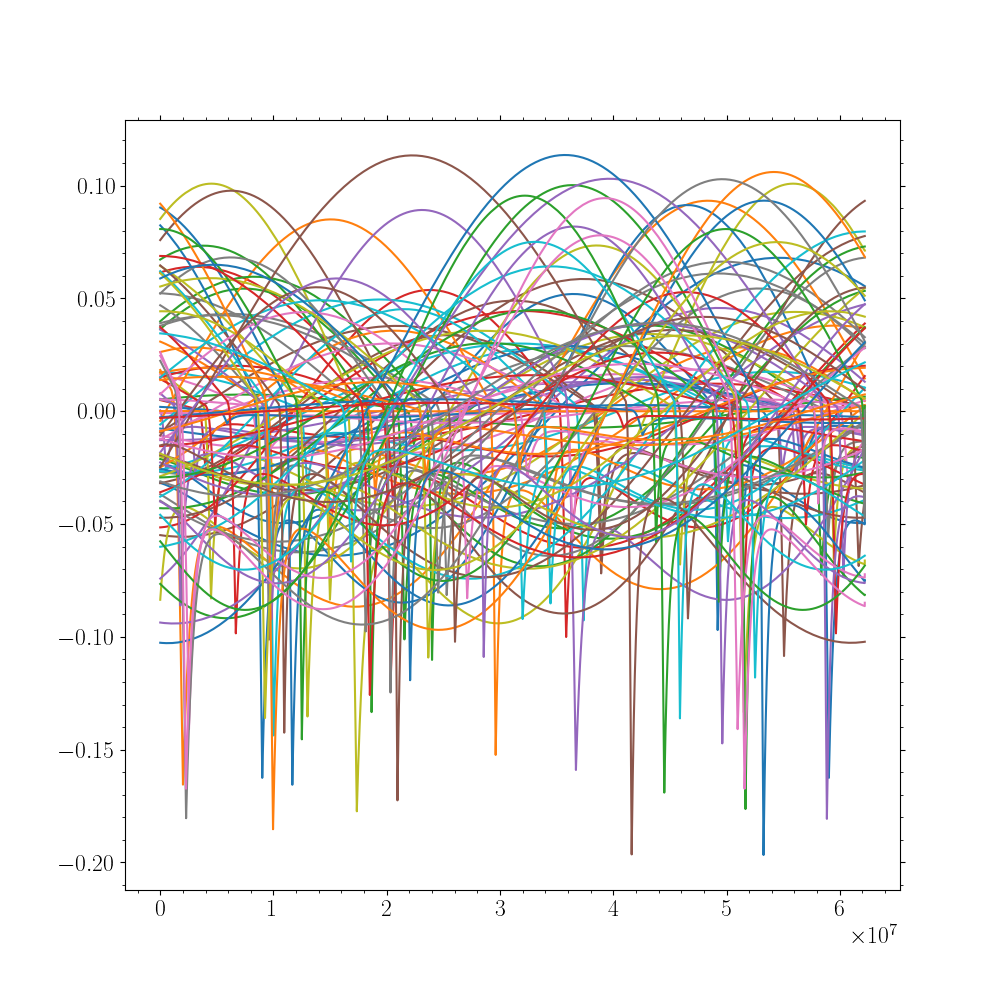

In [10]:
plt.figure(figsize=(10,10))
for i in range(100):
    starID = f'{i+1}'.zfill(9)
    df = pd.read_csv(f'{path}/varsource/varsource_{starID}.txt', sep=' ', names=['time', 'mag'])    
    plt.plot(df.time, df.mag)

### Add magnitude column parameterisation file

In [137]:
starcat = f'{path}/input/starcat_P5_SPF_Ncam24_targets.ftr'
df = pd.read_feather(starcat)

In [16]:
# Generate 1000 random magnitudes reproducable using the seed=1000
rng = np.random.default_rng(seed=1000)
mag = rng.uniform(16, 19, 1000)

# Replace magnitude column in target catalogue
df.mag = mag
df = df.astype({'mag':np.float32})
df.head()

,index,ID,PIC,ra,dec,mag,sample,Teff,R,M,ncams,field,ncon
0,0,000000001,11571238,95.125555,-47.494494,17.564157,8,6322.698412,1.353938,1.240897,24,S,3
1,1,000000002,10612872,88.125215,-49.637731,17.811525,8,5133.584125,4.040686,1.500600,24,S,0
2,2,000000003,16373342,81.625712,-36.698203,17.412825,8,5864.912195,1.276711,1.123527,24,S,1
3,3,000000004,10090932,75.739371,-50.792750,16.609743,8,6264.024256,1.685365,1.331812,24,S,1
4,4,000000005,7792932,89.211789,-55.354966,17.586277,8,6108.070185,2.217076,1.434869,24,S,1


In [18]:
df.to_feather(starcat)

---
## VSC overview
---

In [233]:
paramFile = f'{path}/slurm/cluster.data'

<IPython.core.display.Javascript object>


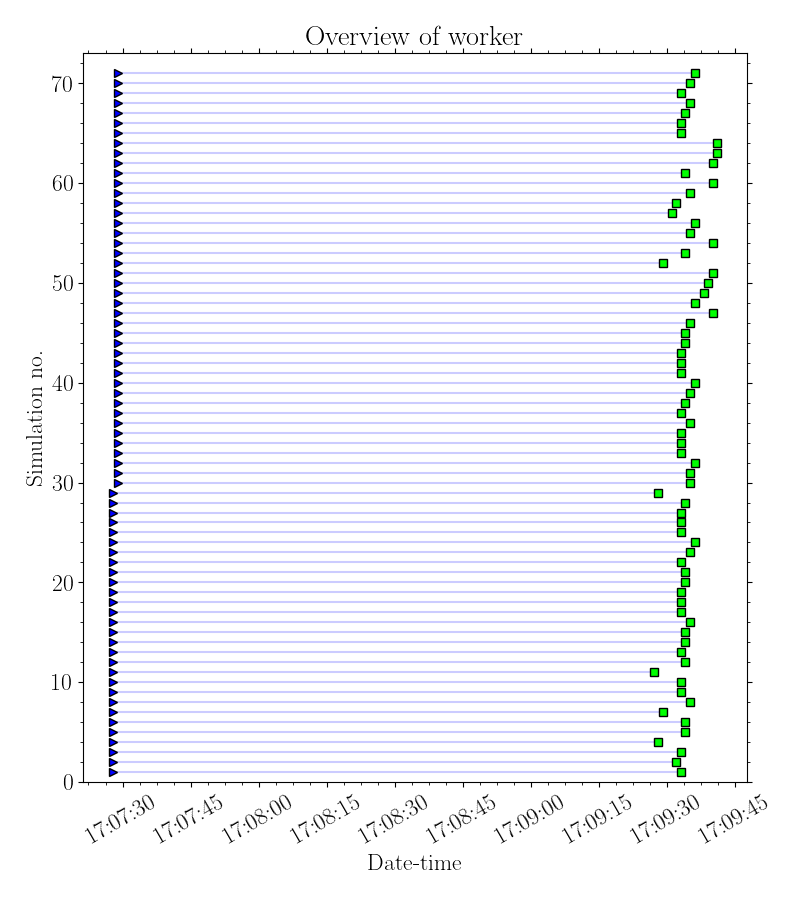

100%|██████████████████████████████████████████████████| 192000/192000 [01:23<00


All simulations finished successfully!
Average walltime per cpu  : 1.265 h
Fastest walltime for cpus : 0.217 h
Slowest walltime for cpus : 2.250 h


In [253]:
workerLog = f'{path}/slurm/slurm_sim1/worker.slurm.log55291090'
df = workerOverview(workerLog, paramFile, ofile=False, plot=True)

---
## Simulation statistics
---

In [232]:
lcs0 = LightCurve(path0, mode="multi")
lcs1 = LightCurve(path1, mode="multi")

### Overview table of simulations

In [224]:
# lcs0.stat_sim_table(f'{path}/table_sims0.ftr')

In [225]:
# lcs1.stat_sim_table(f'{path}/table_sims1.ftr')

### Statistics: LCs per star

In [6]:
# df1 = lcs1.stat_sims()
# df1.head()

In [7]:
# df5 = lcs5.stat_sims()
# df5.head()

### Statistics: LCs per star/quarter

In [9]:
# lcs1.stat_lcsPerStar(quarters=[23,24], ofile='stat_simsPerStarP1.txt')

In [10]:
# lcs.stat_lcsPerStar(quarters=[23,24], ofile='stat_simsPerStarP5.txt')

## LCs per camera

In [11]:
# from platosim.hpc import HPC 
# hpc = HPC(cpus=8)
# # hpc.run(script='platonium', project='kul20', paramFile=paramFile)

In [12]:
# statFile = '/lhome/nicholas/software/workdir/kul20/statistics.txt'
# df = pd.read_csv(statFile)

In [13]:
# df = df.rename(columns={'1': 'star', '1.1':'group', '1.2':'camera', '24':'quarter', '1.3':'flag'})

In [14]:
# df[df.flag == 0]

---
## Merge light curves
---

### Test single camera light curve

<IPython.core.display.Javascript object>


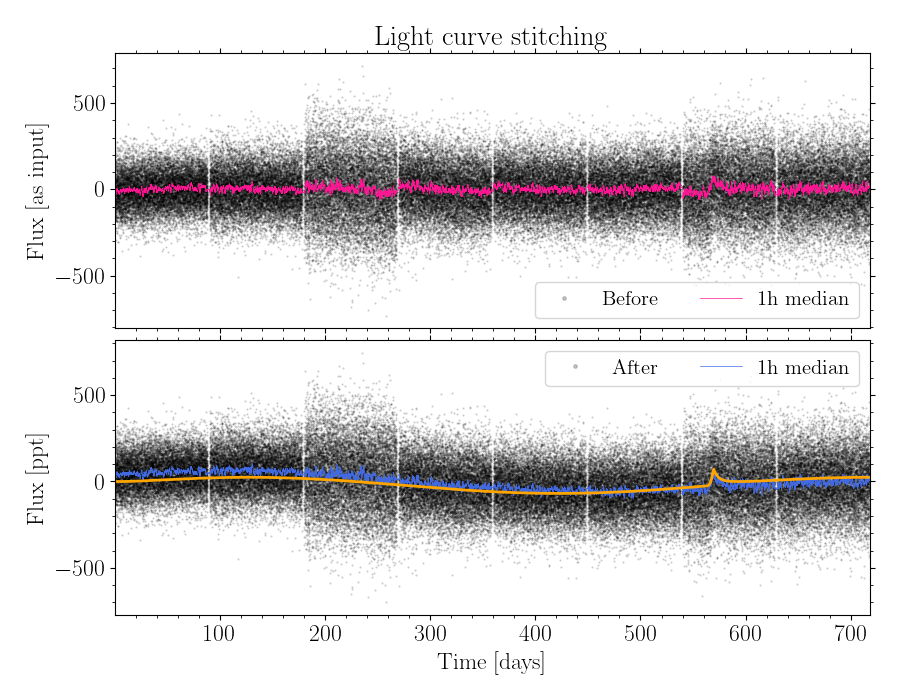

ID                   1
PIC           11571238
ra           95.125555
dec         -47.494494
mag          17.564157
group                1
camera               1
quarter              1
rOA           4.332506
xFP         -17.996888
yFP          -5.269025
ccd                  2
xCCD        220.501372
yCCD       3582.395116
ncon                 0
Name: 0, dtype: object

In [231]:
# Load and unpack data
lcs = LightCurve(f'{path1}/000000001', mode="multi")
lcs.unpack()

# Load all files for a single star/group/camera
files = lcs.files('hdf5', group=1, camera=1)
lc = LightCurve(files[0])

# Load input model and sim-info table
dv = lc.varsource()
ds = lc.star()

# Merge all quarters
df = pd.DataFrame()
df1 = pd.DataFrame()
for f in files:
    lc = LightCurve(f)
    df1['time'] = lc.time()
    df1['flux'] = lc.flux(unit='ppt')
    df = pd.concat([df, df1])
    
# Stitch the light curve
lc = LightCurve(df, mode="multi")
df = lc.stitch(medpoint=1000)

# Plot comparison figure
fig, ax = lc.plot_stitch(df)
plt.plot(dv.time/86400, dv.flux, '-', c='orange', lw=2)
plt.ylabel('Flux [ppt]')
ds

### Test for combined camera light curve

<IPython.core.display.Javascript object>


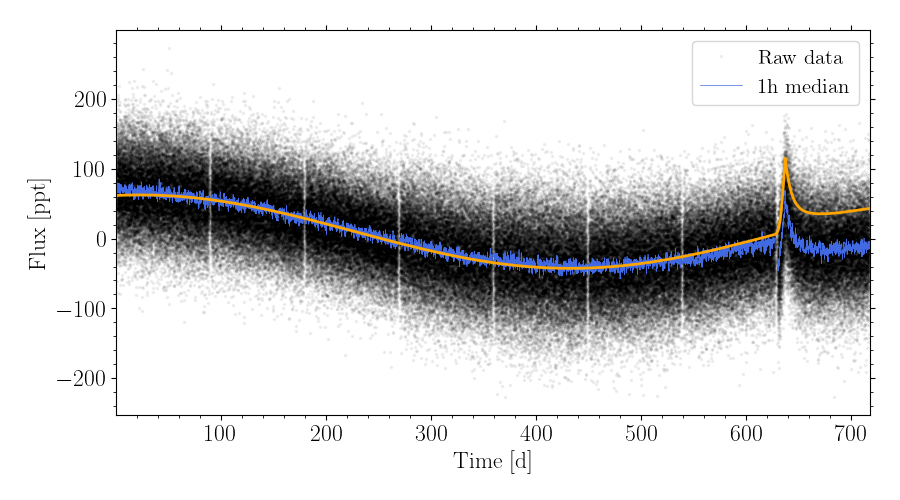

ID                   6
PIC            7765123
ra           84.506209
dec         -55.411079
mag          16.573109
group                1
camera               1
quarter              1
rOA           9.663762
xFP            9.73664
yFP         -41.008218
ccd                  3
xCCD        468.702243
yCCD       2303.987912
ncon                 0
Name: 0, dtype: object

In [201]:
# Load and unpack data
lcs = LightCurve(f'{path2}/000000006', mode="multi")
lcs.unpack()

# Load input model
lc = LightCurve(lcs.files('hdf5')[0])
dv = lc.varsource()
ds = lc.star()

# Perform simple stitching and merge
df = lcs.merge_star(medpoint=1000)

# Plot 
lc = LightCurve(df, 'multi')
lc.plot(median_filter=1, alpha=0.05)
plt.plot(dv.time/86400, dv.flux, '-', c='orange', lw=2)
plt.ylabel('Flux [ppt]')
ds

### Produce final light curves

In [199]:
## Combine the two datasets while reducing each
# from tqdm import tqdm
# for i in tqdm(range(1,1001), bar_format=ut.tqdmBar()):
#     starID = f'{i}'.zfill(9)
    
#     lcs1 = LightCurve(f'{path1}/{starID}', mode="multi")
#     lcs1.unpack()
#     df = lcs1.merge_star()
#     df = df.rename(columns={'flux':'flux0'})
    
#     lcs2 = LightCurve(f'{path2}/{starID}', mode="multi")
#     lcs2.unpack()
#     df2 = lcs2.merge_star()
#     df['flux1'] = df2.flux
    
# #     df = df.reset_index()
#     ofile = f'{path}/finals/{starID}.ftr'
#     df.to_feather(ofile)
#     os.system(f'chmod 755 {ofile}')